## 1. Import the Processed Data

In [25]:
import pandas as pd

X_train = pd.read_csv('../data/processed/X_train_preprocessed.csv')
y_train = pd.read_csv('../data/processed/y_train_preprocessed.csv')['Churn']
X_test = pd.read_csv('../data/processed/X_test_preprocessed.csv')
y_test = pd.read_csv('../data/processed/y_test_preprocessed.csv')['Churn']

## 2. Building the Model

### a. Logistic Regression

In [26]:
# Implementation of Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       936
           1       0.57      0.13      0.21       190

    accuracy                           0.84      1126
   macro avg       0.71      0.56      0.56      1126
weighted avg       0.80      0.84      0.79      1126



c:\Coding SDT\Project\Churn Customer\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


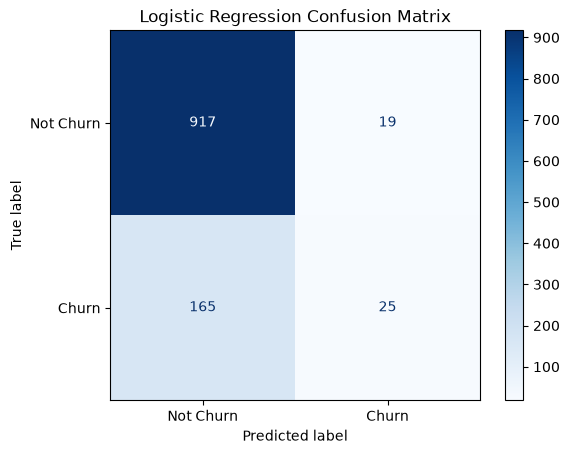

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)

# 2. Initialize the Confusion Matrix Display object
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Not Churn', 'Churn'])

# 3. Plot the matrix (using 'Blues' colormap for a professional look)
disp_log.plot(cmap='Blues')

# 4. Set the title and display the plot
plt.title('Logistic Regression Confusion Matrix')
plt.show()

### b. Decision Tree

In [28]:
# Implementation of Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_clf = DecisionTreeClassifier(max_depth=5,class_weight='balanced', random_state=42)
dt_clf.fit(X_train, y_train)

y_pred_dt = dt_clf.predict(X_test)

print("Decision Tree Results")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
              precision    recall  f1-score   support

           0       0.88      0.68      0.76       936
           1       0.25      0.53      0.34       190

    accuracy                           0.65      1126
   macro avg       0.56      0.60      0.55      1126
weighted avg       0.77      0.65      0.69      1126



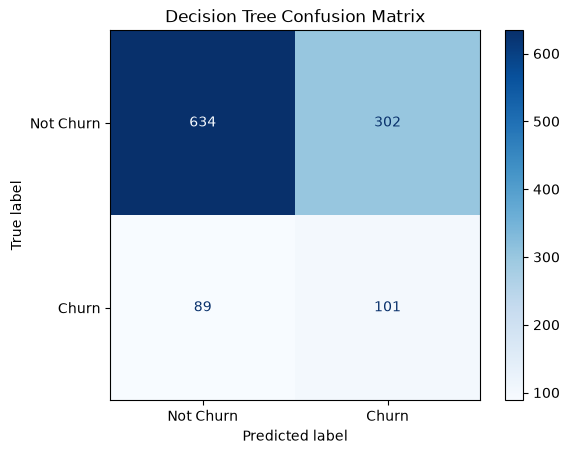

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# 2. Initialize the Confusion Matrix Display object
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Not Churn', 'Churn'])

# 3. Plot the matrix (using 'Blues' colormap for a professional look)
disp_dt.plot(cmap='Blues')

# 4. Set the title and display the plot
plt.title('Decision Tree Confusion Matrix')
plt.show()

### c. Random Forest

In [30]:
# Implementation of Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print("Decision Tree Results")
print(classification_report(y_test, y_pred_rf))

Decision Tree Results
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       936
           1       0.53      0.22      0.31       190

    accuracy                           0.84      1126
   macro avg       0.70      0.59      0.61      1126
weighted avg       0.80      0.84      0.81      1126



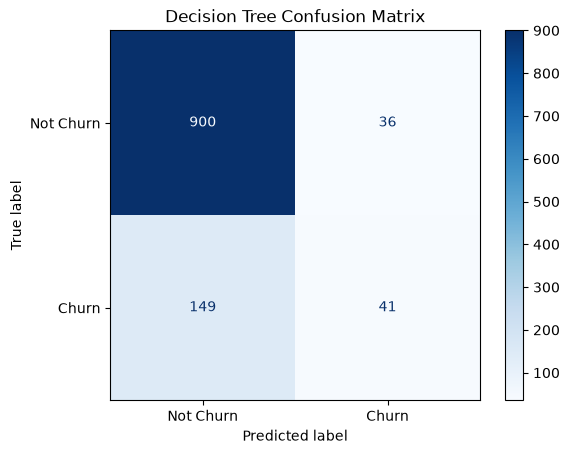

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# 2. Initialize the Confusion Matrix Display object
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Not Churn', 'Churn'])

# 3. Plot the matrix (using 'Blues' colormap for a professional look)
disp_rf.plot(cmap='Blues')

# 4. Set the title and display the plot
plt.title('Decision Tree Confusion Matrix')
plt.show()

### d. XGBoost

In [32]:
# Implementation of XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Initialize the model (scale_pos_weight is used for imbalanced data)
xgb_clf = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train, y_train)

# Generate predictions and probabilities
y_pred_xgb = xgb_clf.predict(X_test)
y_pred_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# Print Evaluation Results
print("--- XGBoost Results ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob_xgb):.4f}")

--- XGBoost Results ---
              precision    recall  f1-score   support

           0       0.86      0.72      0.78       936
           1       0.23      0.42      0.30       190

    accuracy                           0.67      1126
   macro avg       0.55      0.57      0.54      1126
weighted avg       0.75      0.67      0.70      1126

ROC-AUC Score: 0.6385


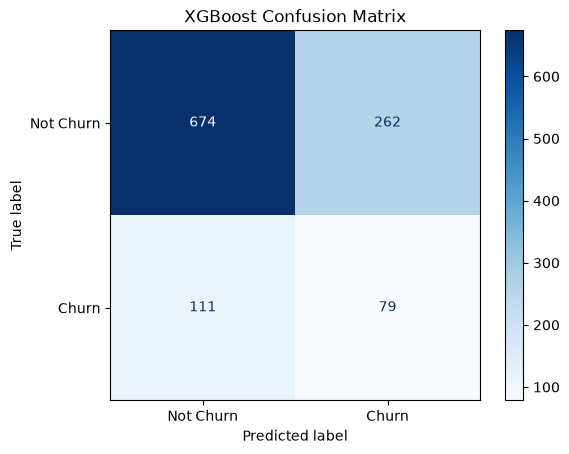

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the Confusion Matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# 2. Initialize the Confusion Matrix Display object
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Not Churn', 'Churn'])

# 3. Plot the matrix (using 'Blues' colormap for a professional look)
disp_xgb.plot(cmap='Blues')

# 4. Set the title and display the plot
plt.title('XGBoost Confusion Matrix')
plt.show()

### e. LightGBM

In [34]:
# Implementation of LightGBM
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

# Initialize the model
lgb_clf = lgb.LGBMClassifier(random_state=42, class_weight='balanced')
lgb_clf.fit(X_train, y_train)

# Generate predictions and probabilities
y_pred_lgb = lgb_clf.predict(X_test)
y_pred_prob_lgb = lgb_clf.predict_proba(X_test)[:, 1]

# Print Evaluation Results
print("--- LightGBM Results ---")
print(classification_report(y_test, y_pred_lgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob_lgb):.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3746, number of negative: 3746
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2038
[LightGBM] [Info] Number of data points in the train set: 7492, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
--- LightGBM Results ---
              precision    recall  f1-score   support

           0       0.87      0.75      0.81       936
           1       0.27      0.44      0.33       190

    accuracy                           0.70      1126
   macro avg       0.57      0.60      0.57      1126
weighted avg       0.77      0.70      0.73      1126

ROC-AUC Score: 0.6717


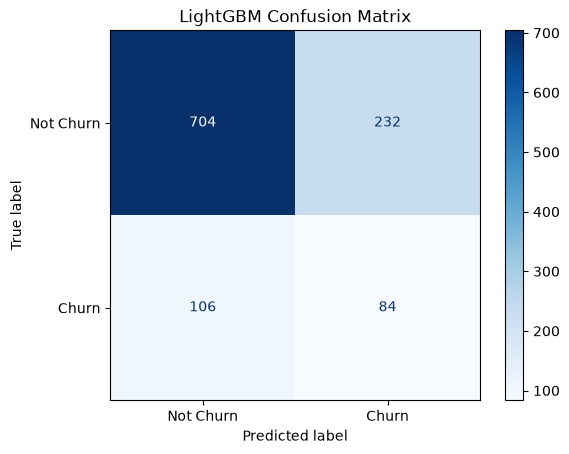

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the Confusion Matrix for LightGBM
cm_lgb = confusion_matrix(y_test, y_pred_lgb)

# 2. Initialize the Confusion Matrix Display object
disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb, display_labels=['Not Churn', 'Churn'])

# 3. Plot the matrix (using 'Blues' colormap for a professional look)
disp_lgb.plot(cmap='Blues')

# 4. Set the title and display the plot
plt.title('LightGBM Confusion Matrix')
plt.show()

## 3. Evaluate Model Before Tuning

### a. ROC-AUC

ROC-AUC Scores Comparison
Logistic Regression : 0.7532
Decision Tree       : 0.5916
Random Forest       : 0.7395
XGBoost             : 0.6385
LightGBM            : 0.6717


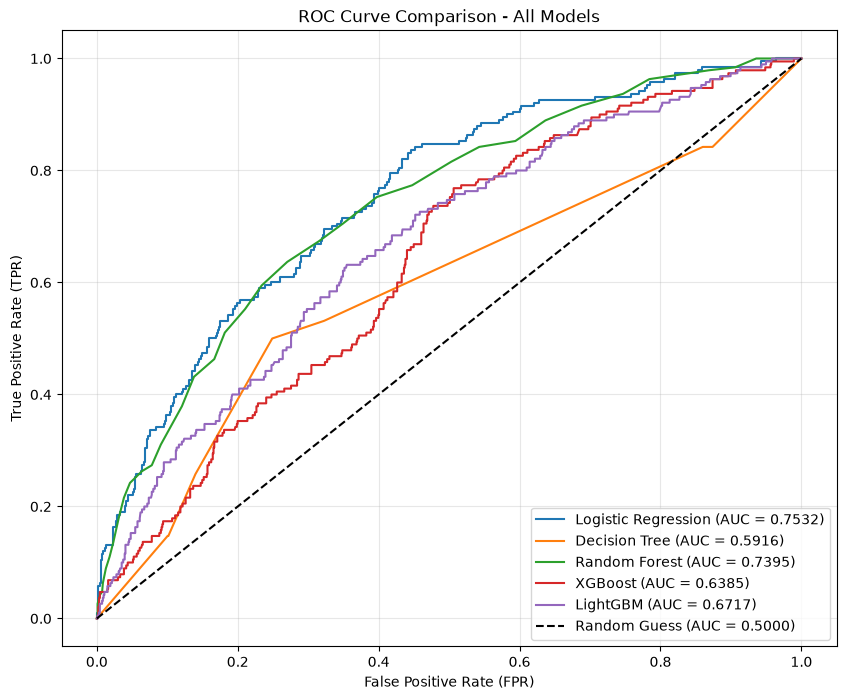

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Calculate probabilities for the positive class (Churn = 1) for all models
y_pred_prob_log = log_reg.predict_proba(X_test)[:, 1]
y_pred_prob_dt = dt_clf.predict_proba(X_test)[:, 1]
y_pred_prob_rf = rf_clf.predict_proba(X_test)[:, 1]
y_pred_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_prob_lgb = lgb_clf.predict_proba(X_test)[:, 1]

# 2. Calculate ROC-AUC scores for all models
roc_auc_log = roc_auc_score(y_test, y_pred_prob_log)
roc_auc_dt = roc_auc_score(y_test, y_pred_prob_dt)
roc_auc_rf = roc_auc_score(y_test, y_pred_prob_rf)
roc_auc_xgb = roc_auc_score(y_test, y_pred_prob_xgb)
roc_auc_lgb = roc_auc_score(y_test, y_pred_prob_lgb)

# Print the final scores
print("ROC-AUC Scores Comparison")
print(f"Logistic Regression : {roc_auc_log:.4f}")
print(f"Decision Tree       : {roc_auc_dt:.4f}")
print(f"Random Forest       : {roc_auc_rf:.4f}")
print(f"XGBoost             : {roc_auc_xgb:.4f}")
print(f"LightGBM            : {roc_auc_lgb:.4f}")

# 3. Calculate False Positive Rates (FPR) and True Positive Rates (TPR) for plotting
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_prob_log)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_prob_xgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_prob_lgb)

# 4. Plot the ROC Curves
plt.figure(figsize=(10, 8))

# Plot each model's curve
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.4f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {roc_auc_lgb:.4f})')

# Plot the random guessing baseline (diagonal dotted line)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random Guess (AUC = 0.5000)')

# Formatting the plot for a professional look
plt.title('ROC Curve Comparison - All Models')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### b. Precision-Recall Curve

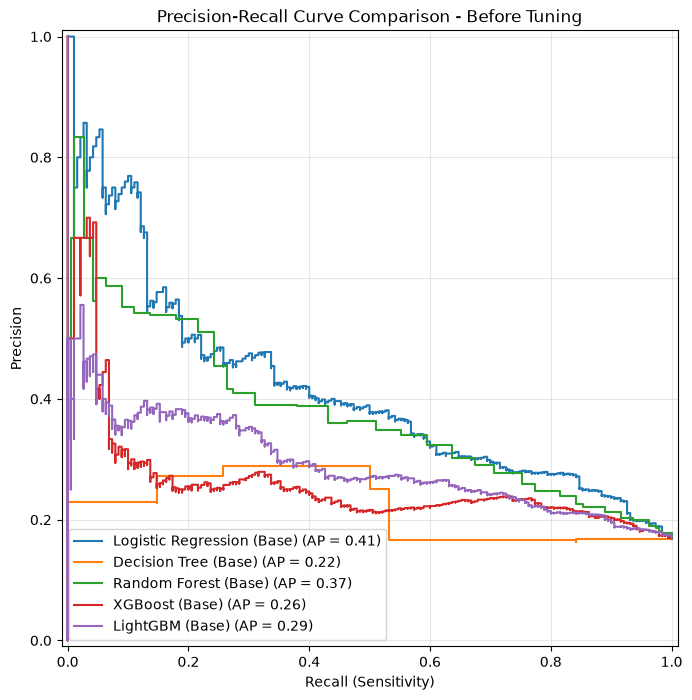

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(10, 8))

# Plot lines using base models (from Section 2)
PrecisionRecallDisplay.from_estimator(log_reg, X_test, y_test, ax=ax, name='Logistic Regression (Base)')
PrecisionRecallDisplay.from_estimator(dt_clf, X_test, y_test, ax=ax, name='Decision Tree (Base)')
PrecisionRecallDisplay.from_estimator(rf_clf, X_test, y_test, ax=ax, name='Random Forest (Base)')
PrecisionRecallDisplay.from_estimator(xgb_clf, X_test, y_test, ax=ax, name='XGBoost (Base)')
PrecisionRecallDisplay.from_estimator(lgb_clf, X_test, y_test, ax=ax, name='LightGBM (Base)')

# Formatting
plt.title('Precision-Recall Curve Comparison - Before Tuning')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()


## 4. Hyperparameter Tuning

In [37]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import pandas as pd

# 1. Define all models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
}

# 2. Define hyperparameter grids for each model
param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 9],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, -1],
        'num_leaves': [31, 50, 100],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    }
}

# 3. Tuning Loop
tuned_models = {}
best_scores = {}

# Iterate over each model to run tuning
for model_name in models.keys():
    print(f"Starting Hyperparameter Tuning for {model_name}...")
    
    # Initialize RandomizedSearchCV (n_iter=10 tests 10 random combinations to save time)
    random_search = RandomizedSearchCV(
        estimator=models[model_name],
        param_distributions=param_grids[model_name],
        n_iter=10,
        scoring='roc_auc',
        cv=3,
        verbose=0,
        random_state=42,
        n_jobs=-1
    )
    
    # Fit the tuner
    random_search.fit(X_train, y_train)
    
    # Save the best model
    best_model = random_search.best_estimator_
    tuned_models[model_name] = best_model
    
    # Evaluate on Test Data
    y_pred_prob_test = best_model.predict_proba(X_test)[:, 1]
    final_test_auc = roc_auc_score(y_test, y_pred_prob_test)
    best_scores[model_name] = final_test_auc
    
    # Print results
    print(f"Best Parameters: {random_search.best_params_}")
    print(f"Final Test ROC-AUC: {final_test_auc:.4f}\n")

# 4. Show Final Ranking Table
print("Final Model Ranking by Test ROC-AUC:")
ranking_df = pd.DataFrame(list(best_scores.items()), columns=['Model', 'Test ROC-AUC'])
# Sort from highest to lowest score
ranking_df = ranking_df.sort_values(by='Test ROC-AUC', ascending=False).reset_index(drop=True)
print(ranking_df)


Starting Hyperparameter Tuning for Logistic Regression...
Best Parameters: {'solver': 'liblinear', 'C': 10}
Final Test ROC-AUC: 0.6569

Starting Hyperparameter Tuning for Decision Tree...
Best Parameters: {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None}
Final Test ROC-AUC: 0.5313

Starting Hyperparameter Tuning for Random Forest...
Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Final Test ROC-AUC: 0.7416

Starting Hyperparameter Tuning for XGBoost...
Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Final Test ROC-AUC: 0.6764

Starting Hyperparameter Tuning for LightGBM...
Best Parameters: {'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Final Test ROC-AUC: 0.7235

Final Model Ranking by Test ROC-AUC:
                 Model  Test ROC-AUC
0        Random Forest      0.741

## 5. Evaluate Model After Tuning

### a. ROC-AUC

ROC-AUC Scores Comparison (After Tuning)
Logistic Regression : 0.6569
Decision Tree       : 0.5313
Random Forest       : 0.7416
XGBoost             : 0.6764
LightGBM            : 0.7235


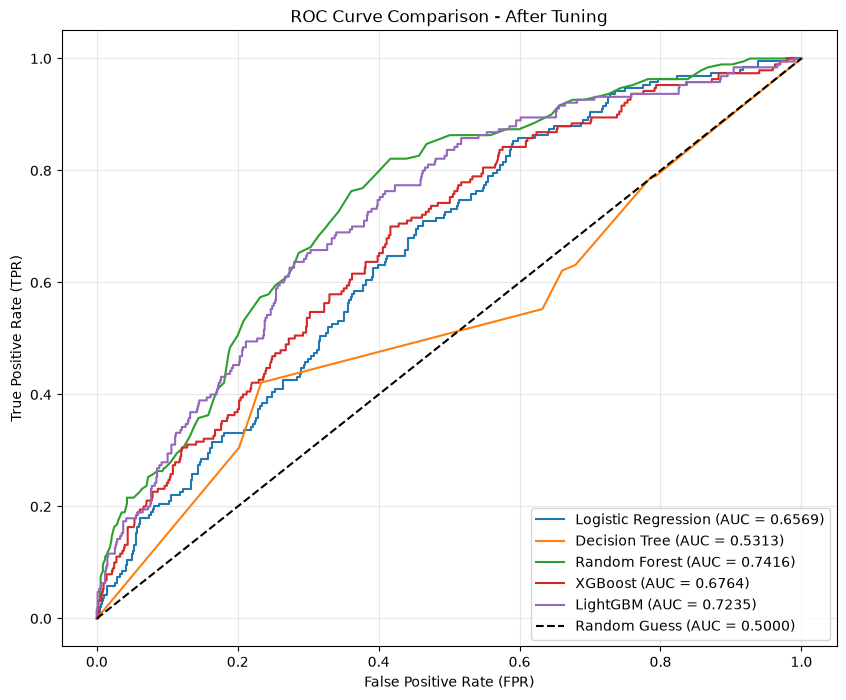

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Calculate probabilities for the positive class (Churn = 1) for all tuned models
y_pred_prob_tuned_log = tuned_models['Logistic Regression'].predict_proba(X_test)[:, 1]
y_pred_prob_tuned_dt = tuned_models['Decision Tree'].predict_proba(X_test)[:, 1]
y_pred_prob_tuned_rf = tuned_models['Random Forest'].predict_proba(X_test)[:, 1]
y_pred_prob_tuned_xgb = tuned_models['XGBoost'].predict_proba(X_test)[:, 1]
y_pred_prob_tuned_lgb = tuned_models['LightGBM'].predict_proba(X_test)[:, 1]

# 2. Calculate ROC-AUC scores for all tuned models
roc_auc_tuned_log = roc_auc_score(y_test, y_pred_prob_tuned_log)
roc_auc_tuned_dt = roc_auc_score(y_test, y_pred_prob_tuned_dt)
roc_auc_tuned_rf = roc_auc_score(y_test, y_pred_prob_tuned_rf)
roc_auc_tuned_xgb = roc_auc_score(y_test, y_pred_prob_tuned_xgb)
roc_auc_tuned_lgb = roc_auc_score(y_test, y_pred_prob_tuned_lgb)

# Print the final scores
print("ROC-AUC Scores Comparison (After Tuning)")
print(f"Logistic Regression : {roc_auc_tuned_log:.4f}")
print(f"Decision Tree       : {roc_auc_tuned_dt:.4f}")
print(f"Random Forest       : {roc_auc_tuned_rf:.4f}")
print(f"XGBoost             : {roc_auc_tuned_xgb:.4f}")
print(f"LightGBM            : {roc_auc_tuned_lgb:.4f}")

# 3. Calculate False Positive Rates (FPR) and True Positive Rates (TPR) for plotting
fpr_t_log, tpr_t_log, _ = roc_curve(y_test, y_pred_prob_tuned_log)
fpr_t_dt, tpr_t_dt, _ = roc_curve(y_test, y_pred_prob_tuned_dt)
fpr_t_rf, tpr_t_rf, _ = roc_curve(y_test, y_pred_prob_tuned_rf)
fpr_t_xgb, tpr_t_xgb, _ = roc_curve(y_test, y_pred_prob_tuned_xgb)
fpr_t_lgb, tpr_t_lgb, _ = roc_curve(y_test, y_pred_prob_tuned_lgb)

# 4. Plot the ROC Curves
plt.figure(figsize=(10, 8))

# Plot each tuned model's curve
plt.plot(fpr_t_log, tpr_t_log, label=f'Logistic Regression (AUC = {roc_auc_tuned_log:.4f})')
plt.plot(fpr_t_dt, tpr_t_dt, label=f'Decision Tree (AUC = {roc_auc_tuned_dt:.4f})')
plt.plot(fpr_t_rf, tpr_t_rf, label=f'Random Forest (AUC = {roc_auc_tuned_rf:.4f})')
plt.plot(fpr_t_xgb, tpr_t_xgb, label=f'XGBoost (AUC = {roc_auc_tuned_xgb:.4f})')
plt.plot(fpr_t_lgb, tpr_t_lgb, label=f'LightGBM (AUC = {roc_auc_tuned_lgb:.4f})')

# Plot the random guessing baseline (diagonal dotted line)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random Guess (AUC = 0.5000)')

# Formatting the plot for a professional look
plt.title('ROC Curve Comparison - After Tuning')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()


### b. Precision-Recall Curve

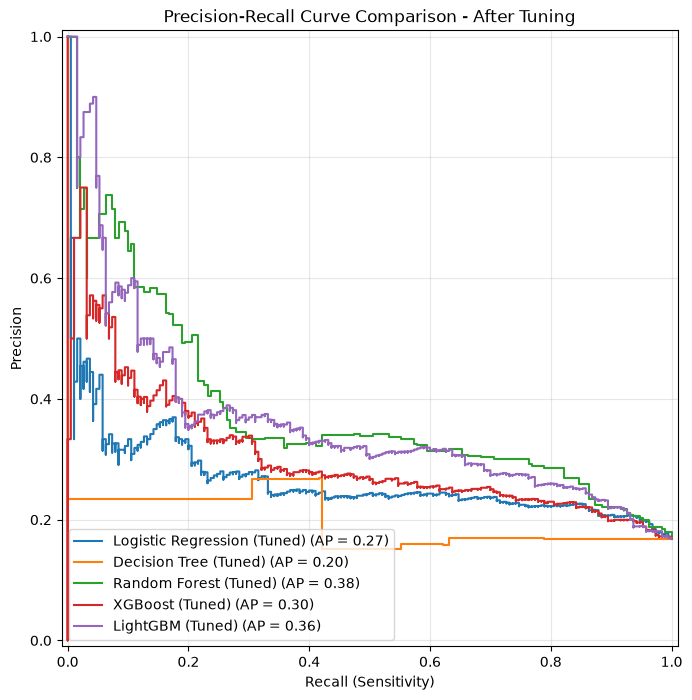

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(10, 8))

# Plot lines using tuned models (from Section 4 dictionary)
PrecisionRecallDisplay.from_estimator(tuned_models['Logistic Regression'], X_test, y_test, ax=ax, name='Logistic Regression (Tuned)')
PrecisionRecallDisplay.from_estimator(tuned_models['Decision Tree'], X_test, y_test, ax=ax, name='Decision Tree (Tuned)')
PrecisionRecallDisplay.from_estimator(tuned_models['Random Forest'], X_test, y_test, ax=ax, name='Random Forest (Tuned)')
PrecisionRecallDisplay.from_estimator(tuned_models['XGBoost'], X_test, y_test, ax=ax, name='XGBoost (Tuned)')
PrecisionRecallDisplay.from_estimator(tuned_models['LightGBM'], X_test, y_test, ax=ax, name='LightGBM (Tuned)')

# Formatting
plt.title('Precision-Recall Curve Comparison - After Tuning')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()


## 6. Feature Importance

Feature Importance Table (XGBoost Tuned)
                                  Feature  Importance
0                                  Tenure    0.152141
27                  MaritalStatus_Married    0.079089
16  PreferredPaymentMode_Cash on Delivery    0.076235
23    PreferedOrderCat_Laptop & Accessory    0.058572
20               PreferredPaymentMode_UPI    0.046835
19          PreferredPaymentMode_E wallet    0.043210
17       PreferredPaymentMode_Credit Card    0.042824
18        PreferredPaymentMode_Debit Card    0.036578
22               PreferedOrderCat_Grocery    0.032926
15               PreferredPaymentMode_COD    0.032195


C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_8780\150022142.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')


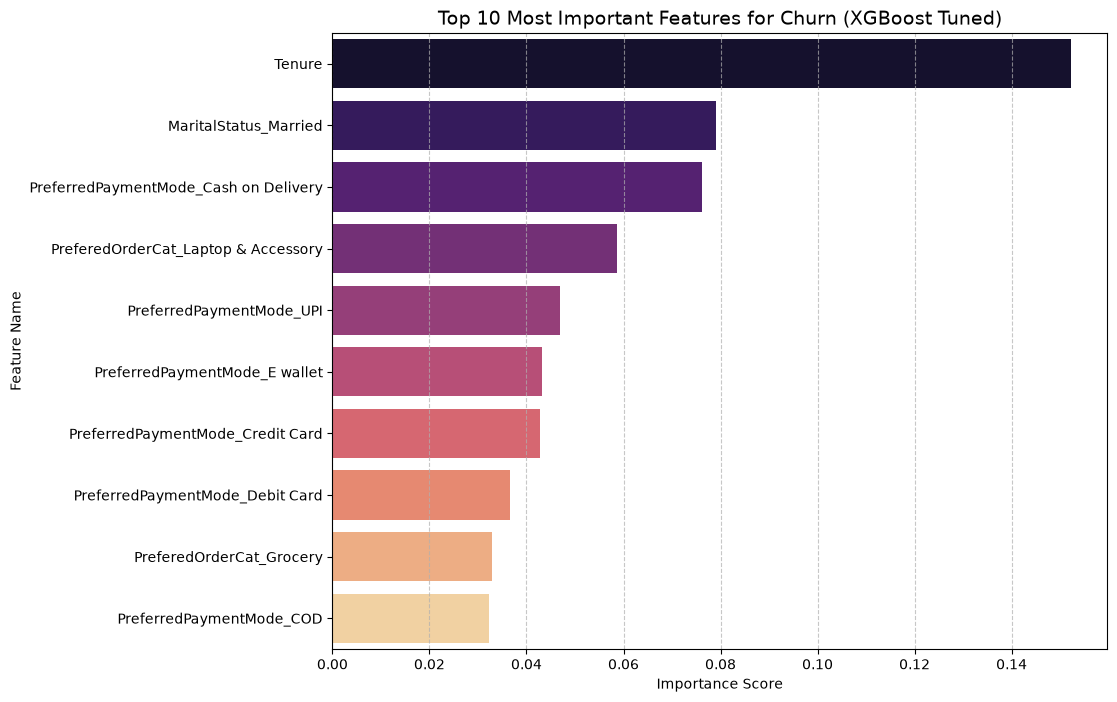

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# You can easily change this to 'Random Forest' or 'LightGBM'
model_name = 'XGBoost'
best_model = tuned_models[model_name]

# Get feature importances from the tuned model
importance = best_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame and sort it
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Print the top 10 table
print(f"Feature Importance Table ({model_name} Tuned)")
print(feature_importance_df.head(10))

# Plot the Feature Importance
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')

# Formatting the plot
plt.title(f'Top 10 Most Important Features for Churn ({model_name} Tuned)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## 7. Export Model Output

In [43]:
import joblib
import os

# 1. Create a folder named 'models' if it doesn't exist yet
os.makedirs('../models', exist_ok=True)

# 2. Iterate through all tuned models and save them one by one
print("Exporting Tuned Models...")
for model_name, model_object in tuned_models.items():
    
    # Format the filename (e.g., 'Random Forest' becomes 'random_forest')
    safe_name = model_name.replace(' ', '_').lower()
    model_filepath = f'../models/tuned_{safe_name}.pkl'
    
    # Export / Save the model
    joblib.dump(model_object, model_filepath)
    
    print(f"[{model_name}] successfully saved to {model_filepath}")

print("\nAll models have been successfully exported!")


Exporting Tuned Models...
[Logistic Regression] successfully saved to ../models/tuned_logistic_regression.pkl
[Decision Tree] successfully saved to ../models/tuned_decision_tree.pkl
[Random Forest] successfully saved to ../models/tuned_random_forest.pkl
[XGBoost] successfully saved to ../models/tuned_xgboost.pkl
[LightGBM] successfully saved to ../models/tuned_lightgbm.pkl

All models have been successfully exported!
